Plots notebook

In [1]:
import utils as ut
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle as pkl

2025-02-03 08:50:07.513959: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-03 08:50:07.525035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738569007.537877  969537 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738569007.541953  969537 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-03 08:50:07.555764: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
ds_folds = ut.siamese_noise_dataset_fold_range(test_size=0.2, noise_size=1, n_splits=5)

Total dataset size: 3150
Number of T1 images: 1476
Number of T2 images: 1674


In [3]:
ds_folds[0]['train'][120]['slice2'].save("imt1.png")

In [3]:
im1 = Image.open("noise_site/imt1.png")
im2 = Image.open("noise_site/imt2.png")
ut.add_noise_range(im1, 9).size

(224, 224)

In [63]:
im1.resize((4,4))

In [ ]:
from matplotlib import gridspec
fig = plt.figure(figsize=(4, 15))
gs = gridspec.GridSpec(10, 2, figure=fig)
gs.update(wspace=0.04)  # Adjust horizontal spacing

for i in range(10):
    ax1 = fig.add_subplot(gs[i, 0])
    ax2 = fig.add_subplot(gs[i, 1])

    im_noise1 = ut.add_noise_range(im1, i)
    im_noise2 = ut.add_noise_range(im2, i)

    ax1.imshow(im_noise1, cmap='gray')
    ax1.axis('off')
    ax2.imshow(im_noise2, cmap='gray')
    ax2.axis('off')

Logs were downloaded manually.  

In [2]:
df = pd.read_csv('../logs/9_mat.csv')

for i in range(6):
    subdf = df.iloc[i*4:i*4+4]

    # Create confusion matrix
    cm = subdf.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
    tn, fp, fn, tp = cm.values.ravel()
    total = tn + fp + fn + tp

    accuracy = (tn + tp) / total
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall)

    print(f"{subdf['name'].values[0][16:-11]}, {accuracy}, {f1_score}")


VIT, 1.0, 1.0
VGGNet, 1.0, 1.0
MobNet, 0.9841772151898734, 0.984894259818731
EffNet, 0.5917721518987342, 0.4109589041095891
ResNeXt, 0.5917721518987342, 0.6366197183098592
ResNet, 1.0, 1.0


In [3]:
accuracies = {0:[],1:[], 2:[], 3:[], 4:[], 5:[]}
for j in range(10):

    df = pd.read_csv(f'../logs/{j}_mat.csv')


    for i in range(6):
        subdf = df.iloc[i*4:i*4+4]

        # Create confusion matrix
        cm = subdf.pivot_table(values='nPredictions', index='Actual', columns='Predicted', aggfunc='sum')
        tn, fp, fn, tp = cm.values.ravel()
        total = tn + fp + fn + tp

        accuracy = (tn + tp) / total
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        f1_score = 2 * (precision * recall) / (precision + recall)

        # print(f"{subdf['name'].values[0][16:-11]}, {accuracy}, {f1_score}")
        if accuracy < 0.5:
            accuracy = 0.5
        if accuracy == 1.0:
            accuracy = 0.99

        accuracies[i].append(accuracy)

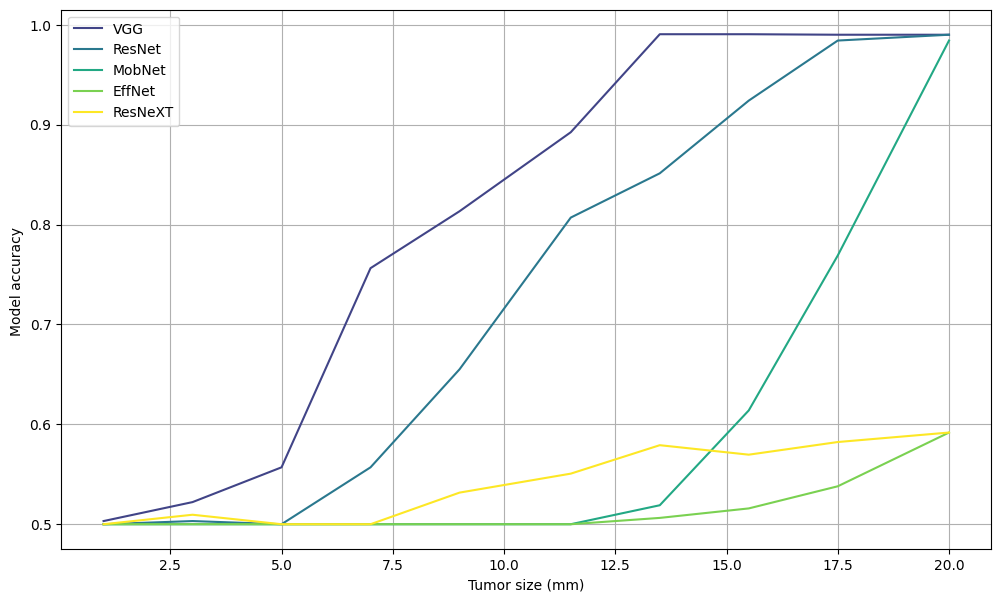

In [4]:
# accuracies[0]
sizes = [int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)]
colors = plt.cm.viridis(np.linspace(0,1,6))
# plt.cm.

plt.figure(figsize=(12,7))
# plt.plot(sizes, accuracies[0], label='ViT',     color = colors[0])
plt.plot(sizes, accuracies[1], label='VGG',     color = colors[1])
plt.plot(sizes, accuracies[5], label='ResNet',  color = colors[2])
plt.plot(sizes, accuracies[2], label='MobNet',  color = colors[3])
plt.plot(sizes, accuracies[3], label='EffNet',  color = colors[4])
plt.plot(sizes, accuracies[4], label='ResNeXT', color = colors[5])
plt.xlabel('Tumor size (mm)')
plt.ylabel('Model accuracy ')
plt.grid()

plt.legend()
plt.show()

/tmp/ipykernel_969537/4293401616.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


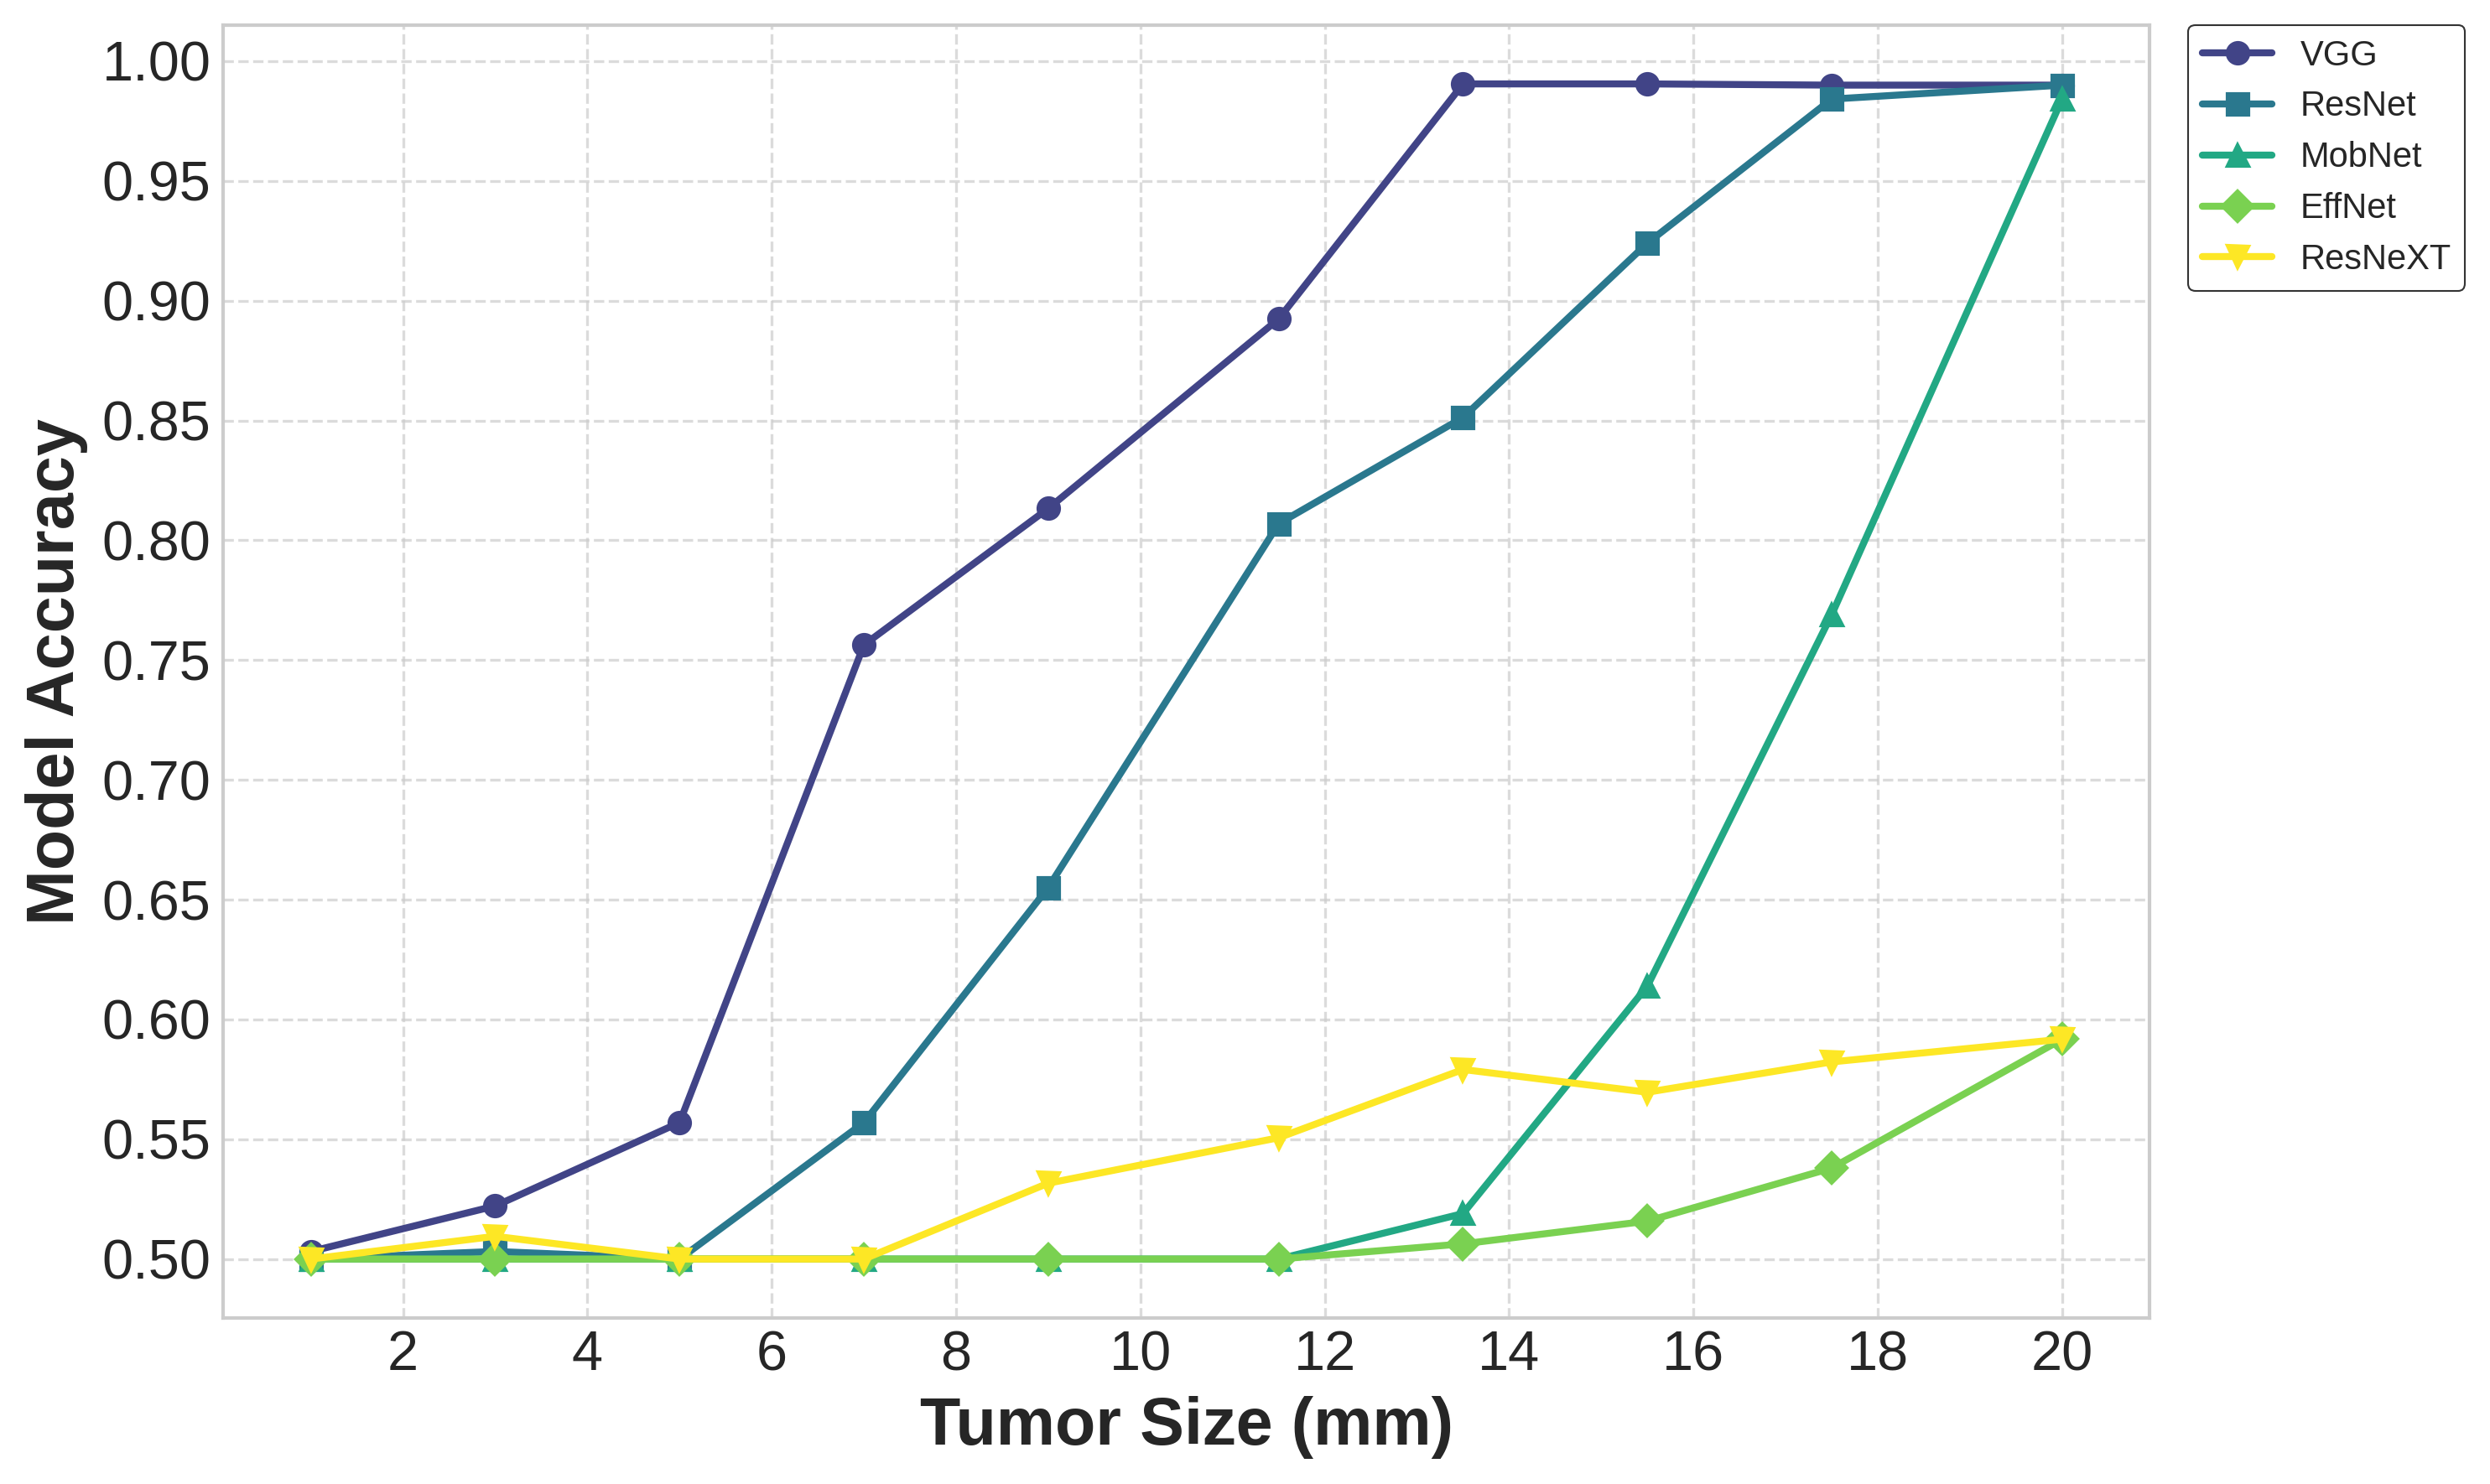

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

# Set the style to a clean, professional look
plt.style.use('seaborn-whitegrid')

# Define data
sizes = [int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)]
colors = plt.cm.viridis(np.linspace(0, 1, 6))

# Create figure with higher DPI for better quality
plt.figure(figsize=(10, 6), dpi=300)

# Plot lines with increased line width and markers
plt.plot(sizes, accuracies[1], label='VGG',     color=colors[1], linewidth=2, marker='o', markersize=6)
plt.plot(sizes, accuracies[5], label='ResNet',  color=colors[2], linewidth=2, marker='s', markersize=6)
plt.plot(sizes, accuracies[2], label='MobNet',  color=colors[3], linewidth=2, marker='^', markersize=6)
plt.plot(sizes, accuracies[3], label='EffNet',  color=colors[4], linewidth=2, marker='D', markersize=6)
plt.plot(sizes, accuracies[4], label='ResNeXT', color=colors[5], linewidth=2, marker='v', markersize=6)

# Customize axes
plt.xlabel('Tumor Size (mm)', fontsize=19, fontweight='bold')
plt.ylabel('Model Accuracy', fontsize=19, fontweight='bold')

# Customize grid
plt.grid(True, linestyle='--', alpha=0.7)

# Customize ticks
plt.tick_params(axis='both', which='major', labelsize=16)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_major_locator(MultipleLocator(0.05))

# Add legend with enhanced styling
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', 
                   borderaxespad=0., frameon=True, fontsize=10)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.5)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Optional: Save the figure with high resolution
# plt.savefig('tumor_size_accuracy.pdf', dpi=300, bbox_inches='tight')
plt.savefig("acc_vs_size.eps")
plt.show()

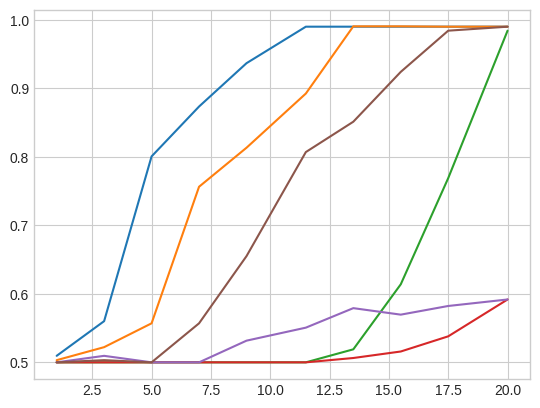

In [6]:
import seaborn as sns

# sns.reset_defaults()

sns.lineplot(x=sizes, y=accuracies[0])
sns.lineplot(x=sizes, y=accuracies[1])
sns.lineplot(x=sizes, y=accuracies[2])
sns.lineplot(x=sizes, y=accuracies[3])
sns.lineplot(x=sizes, y=accuracies[4])
sns.lineplot(x=sizes, y=accuracies[5])
plt.show()



In [7]:
import nibabel as nib
nii = nib.load('/home/data/dhcp_mri/sourcedata/sub-CC00069XX12/ses-26300/anat/sub-CC00069XX12_ses-26300_T1w.nii.gz')
sx, sy, sz = nii.header.get_zooms()

In [8]:
nii.header.get_zooms()

(0.5, 0.5, 0.5)

In [9]:
import nibabel as nib
import numpy as np

def get_voxel_coordinates(nifti_img, i, j, k):
    """
    Convert voxel indices (i,j,k) to real-world coordinates (x,y,z) in mm
    
    Parameters:
    nifti_img: NiBabel image object
    i,j,k: voxel indices
    
    Returns:
    x,y,z: real-world coordinates in mm
    """
    # Get the affine transformation matrix
    affine = nifti_img.affine
    
    # Create voxel coordinates array (adding 1 for homogeneous coordinates)
    voxel_coords = np.array([i, j, k, 1])
    
    # Apply the affine transformation
    world_coords = np.dot(affine, voxel_coords)
    
    # Return x,y,z coordinates
    return world_coords[:3]

def get_voxel_from_coordinates(nifti_img, x, y, z):
    """
    Convert real-world coordinates (x,y,z) in mm to nearest voxel indices (i,j,k)
    
    Parameters:
    nifti_img: NiBabel image object
    x,y,z: real-world coordinates in mm
    
    Returns:
    i,j,k: voxel indices
    """
    # Get the inverse of the affine transformation matrix
    inverse_affine = np.linalg.inv(nifti_img.affine)
    
    # Create world coordinates array (adding 1 for homogeneous coordinates)
    world_coords = np.array([x, y, z, 1])
    
    # Apply the inverse transformation
    voxel_coords = np.dot(inverse_affine, world_coords)
    
    # Round to nearest voxel and convert to int
    return np.round(voxel_coords[:3]).astype(int)

# Example usage:
def demonstrate_coordinate_mapping(nifti_path):
    # Load the NIfTI image
    img = nib.load(nifti_path)
    
    # Get image dimensions
    dims = img.shape
    print(f"Image dimensions: {dims}")
    
    # Get voxel sizes
    voxel_sizes = img.header.get_zooms()
    print(f"Voxel sizes (mm): {voxel_sizes}")
    
    # Example: Convert center voxel to world coordinates
    center_voxel = [dim//2 for dim in dims]
    world_coords = get_voxel_coordinates(img, *center_voxel)
    print(f"\nCenter voxel indices: {center_voxel}")
    print(f"Corresponding world coordinates (mm): {world_coords}")
    
    # Convert back to voxel coordinates
    voxel_indices = get_voxel_from_coordinates(img, *world_coords)
    print(f"Converting back to voxel indices: {voxel_indices}")

In [10]:
demonstrate_coordinate_mapping("/home/data/dhcp_mri/sourcedata/sub-CC00069XX12/ses-26300/anat/sub-CC00069XX12_ses-26300_T1w.nii.gz")

Image dimensions: (290, 290, 203)
Voxel sizes (mm): (0.5, 0.5, 0.5)

Center voxel indices: [145, 145, 101]
Corresponding world coordinates (mm): [-5.796875   14.30178833 18.1431427 ]
Converting back to voxel indices: [145 145 101]


In [11]:
# Get the voxel indices corresponding to world coordinate (0,0,0)
world_origin_voxels = get_voxel_from_coordinates(nii, 0, 0, 0)
print(f"World origin (0,0,0) is at voxel: {world_origin_voxels}")

# Get volume center for comparison
volume_center = [dim//2 for dim in nii.shape]
print(f"Volume center is at voxel: {volume_center}")

# Get world coordinates of volume center
center_world = get_voxel_coordinates(nii, *volume_center)
print(f"Volume center in world coordinates: {center_world}")

World origin (0,0,0) is at voxel: [133 116  65]
Volume center is at voxel: [145, 145, 101]
Volume center in world coordinates: [-5.796875   14.30178833 18.1431427 ]


In [12]:
import nibabel as nib
import numpy as np

def get_slice_dimensions(nifti_img, slice_index, axis=2):
    """
    Calculate the real-world dimensions and coordinates of a slice
    
    Parameters:
    nifti_img: NiBabel image object
    slice_index: Index of the slice
    axis: Axis along which to take the slice (0=sagittal, 1=coronal, 2=axial)
    
    Returns:
    dict containing slice dimensions and corner coordinates
    """
    # Get image dimensions
    dims = nifti_img.shape
    
    # Create meshgrid of voxel coordinates for the slice
    if axis == 0:  # Sagittal (YZ plane)
        y, z = np.meshgrid(range(dims[1]), range(dims[2]), indexing='ij')
        x = np.full_like(y, slice_index)
        grid = np.stack([x, y, z])
    elif axis == 1:  # Coronal (XZ plane)
        x, z = np.meshgrid(range(dims[0]), range(dims[2]), indexing='ij')
        y = np.full_like(x, slice_index)
        grid = np.stack([x, y, z])
    else:  # axis == 2, Axial (XY plane)
        x, y = np.meshgrid(range(dims[0]), range(dims[1]), indexing='ij')
        z = np.full_like(x, slice_index)
        grid = np.stack([x, y, z])
    
    # Reshape grid to list of points
    points = grid.reshape(3, -1)
    
    # Add homogeneous coordinate
    points = np.vstack([points, np.ones(points.shape[1])])
    
    # Transform all points to world coordinates
    world_points = nifti_img.affine @ points
    
    # Get corners in world coordinates
    corners = {
        'top_left': world_points[:3, 0],
        'top_right': world_points[:3, dims[0]-1],
        'bottom_left': world_points[:3, -dims[0]],
        'bottom_right': world_points[:3, -1]
    }
    
    # Calculate dimensions
    width = np.linalg.norm(corners['top_right'] - corners['top_left'])
    height = np.linalg.norm(corners['bottom_left'] - corners['top_left'])
    
    return {
        'dimensions_mm': (width, height),
        'corners_mm': corners
    }

# Example usage
def print_slice_info(nifti_path, slice_index=None, axis=2):
    img = nib.load(nifti_path)
    
    # If no slice index provided, use middle slice
    if slice_index is None:
        slice_index = img.shape[axis] // 2
    
    # Get slice information
    slice_info = get_slice_dimensions(img, slice_index, axis)
    
    # Print results
    print(f"\nSlice {slice_index} along axis {axis}:")
    print(f"Physical dimensions (width × height): {slice_info['dimensions_mm'][0]:.2f}mm × {slice_info['dimensions_mm'][1]:.2f}mm")
    print("\nCorner coordinates (x, y, z) in mm:")
    for corner, coords in slice_info['corners_mm'].items():
        print(f"{corner}: ({coords[0]:.2f}, {coords[1]:.2f}, {coords[2]:.2f})")

In [13]:
# For an axial slice (default)
slice_info = get_slice_dimensions(nii, slice_index=100)  # or whatever slice you want

# For a sagittal slice
sagittal_info = get_slice_dimensions(nii, slice_index=100, axis=0)

# For a coronal slice
coronal_info = get_slice_dimensions(nii, slice_index=100, axis=1)

In [14]:
slice_info

{'dimensions_mm': (144.5, 144.5),
 'corners_mm': {'top_left': array([ 66.703125  , -58.19821167,  17.6431427 ]),
  'top_right': array([66.703125  , 86.30178833, 17.6431427 ]),
  'bottom_left': array([-77.796875  , -58.19821167,  17.6431427 ]),
  'bottom_right': array([-77.796875  ,  86.30178833,  17.6431427 ])}}

In [15]:
import pickle as pkl

dic_res = pkl.load(open("../noise_size_results59.pkl", "rb"))
dic_res

{5: {0: {'loss': 9.761034429073334,
   'accuracy': 0.4825949367088608,
   'precision': 0.4510374493927125,
   'recall': 0.35119047619047616,
   'f1': 0.3326459210376607},
  1: {'loss': 8.92701280117035,
   'accuracy': 0.5063291139240507,
   'precision': 0.5275229357798166,
   'recall': 0.3958333333333333,
   'f1': 0.3759715025906736},
  2: {'loss': 7.637828677892685,
   'accuracy': 0.5506329113924051,
   'precision': 0.6608917539618586,
   'recall': 0.47916666666666663,
   'f1': 0.4933276698169976},
  3: {'loss': 6.627840101718903,
   'accuracy': 0.6170886075949367,
   'precision': 0.7148793488851952,
   'recall': 0.6041666666666666,
   'f1': 0.6020063820893696},
  4: {'loss': 5.83916163444519,
   'accuracy': 0.6487341772151898,
   'precision': 0.7330554894022385,
   'recall': 0.6636904761904763,
   'f1': 0.6499833325396447},
  5: {'loss': 5.1692570596933365,
   'accuracy': 0.6993670886075949,
   'precision': 0.7519980708281659,
   'recall': 0.7589285714285714,
   'f1': 0.7305327522718

In [16]:

noise_sizes = sorted(dic_res[5].keys())
accuracies_5 = [dic_res[5][size]['accuracy'] for size in noise_sizes]
[0.5 if a<0.5 else a for a in accuracies_5]
noise_sizes
# [int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

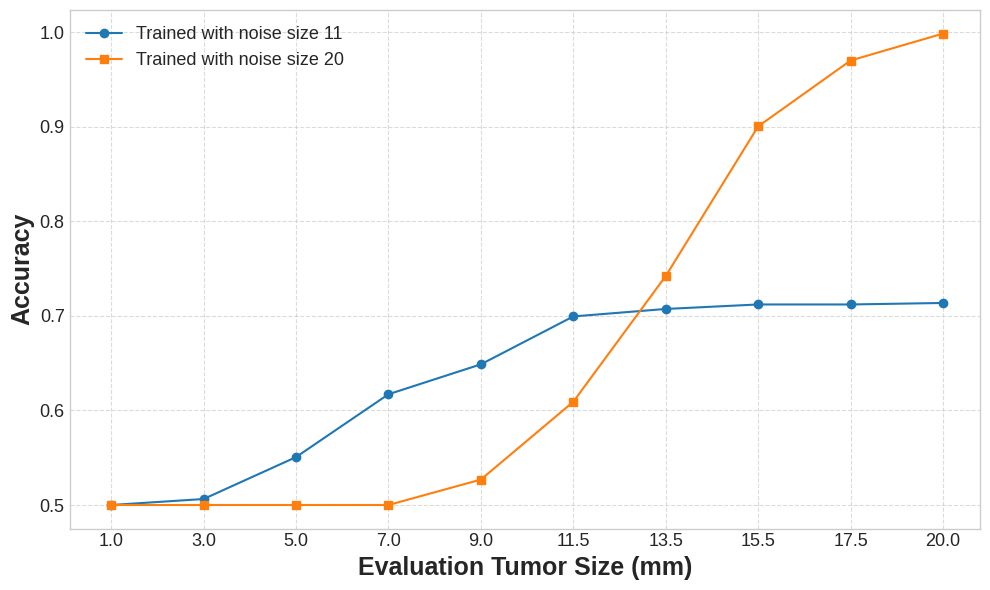

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_accuracies(results):
    noise_sizes = sorted(results[5].keys())
    # noise_sizes = [int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)] # size in mm
    accuracies_5 = [results[5][size]['accuracy'] for size in noise_sizes]
    accuracies_5 = [0.5 if a<0.5 else a for a in accuracies_5]
    accuracies_9 = [results[9][size]['accuracy'] for size in noise_sizes]
    accuracies_9 = [0.5 if a<0.5 else a for a in accuracies_9]

    plt.figure(figsize=(10, 6))
    plt.plot(noise_sizes, accuracies_5, 'o-', label='Trained with noise size 11')
    plt.plot(noise_sizes, accuracies_9, 's-', label='Trained with noise size 20')
    
    plt.xlabel('Evaluation Tumor Size (mm)', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    # plt.title('Model Performance Across Different Noise Sizes')
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.xticks(ticks=range(10),labels=[int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)])

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize = 13)
    
    # # Add value annotations
    # for i, (acc5, acc9) in enumerate(zip(accuracies_5, accuracies_9)):
    #     plt.annotate(f'{acc5:.2f}', (i, acc5), textcoords="offset points", xytext=(0,10), ha='center')
    #     plt.annotate(f'{acc9:.2f}', (i, acc9), textcoords="offset points", xytext=(0,-15), ha='center')
    plt.xlim(right=9.4)
    
    plt.tight_layout()
    plt.show()

plot_accuracies(dic_res)

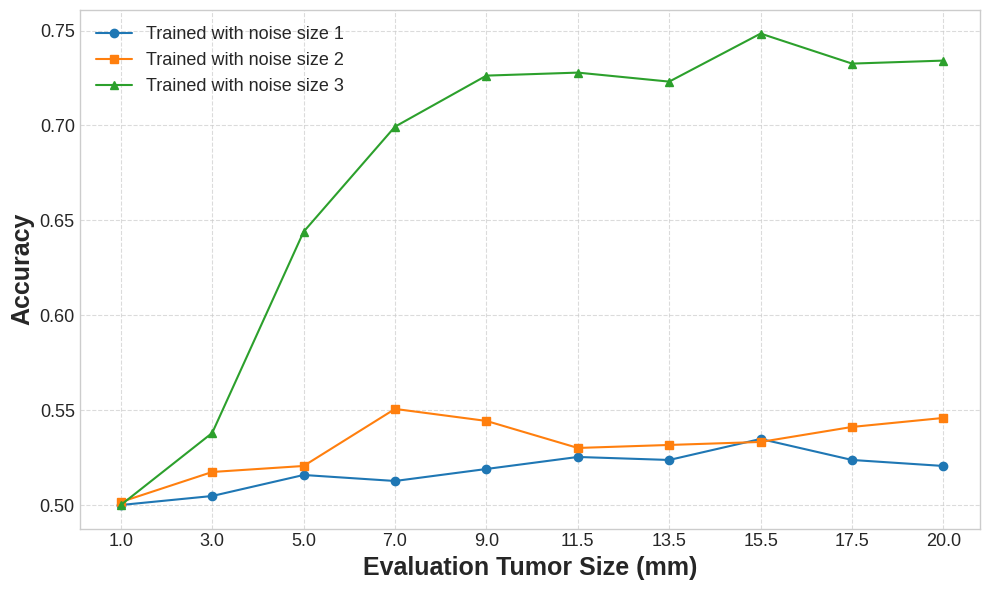

In [18]:
dic_res2 = pkl.load(open("../noise_size_results_123.pkl", "rb"))

def plot_accuracies2(results):
    noise_sizes = sorted(results[1].keys())
    # noise_sizes = [int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)] # size in mm
    accuracies_1 = [results[1][size]['accuracy'] for size in noise_sizes]
    accuracies_1 = [0.5 if a<0.5 else a for a in accuracies_1]
    accuracies_2 = [results[2][size]['accuracy'] for size in noise_sizes]
    accuracies_2 = [0.5 if a<0.5 else a for a in accuracies_2]
    accuracies_3 = [results[3][size]['accuracy'] for size in noise_sizes]
    accuracies_3 = [0.5 if a<0.5 else a for a in accuracies_3]

    plt.figure(figsize=(10, 6))
    plt.plot(noise_sizes, accuracies_1, 'o-', label='Trained with noise size 1')
    plt.plot(noise_sizes, accuracies_2, 's-', label='Trained with noise size 2')
    plt.plot(noise_sizes, accuracies_3, '^-', label='Trained with noise size 3')
    
    plt.xlabel('Evaluation Tumor Size (mm)', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    # plt.title('Model Performance Across Different Noise Sizes')
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.xticks(ticks=range(10),labels=[int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)])

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize = 13)
    
    # # Add value annotations
    # for i, (acc5, acc9) in enumerate(zip(accuracies_5, accuracies_9)):
    #     plt.annotate(f'{acc5:.2f}', (i, acc5), textcoords="offset points", xytext=(0,10), ha='center')
    #     plt.annotate(f'{acc9:.2f}', (i, acc9), textcoords="offset points", xytext=(0,-15), ha='center')
    plt.xlim(right=9.4)
    
    plt.tight_layout()
    plt.show()

plot_accuracies2(dic_res2)

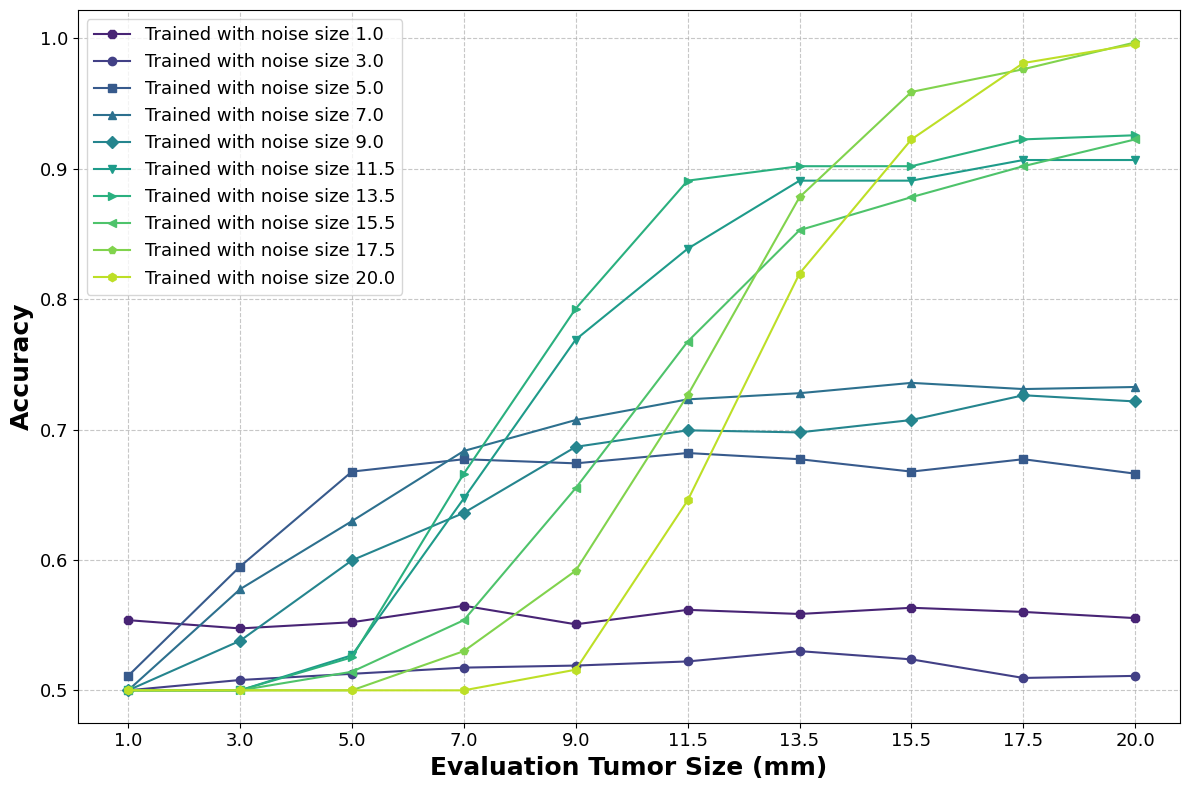

In [2]:
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

dic_res2 = pkl.load(open("../noise_size_results_all.pkl", "rb"))

def plot_accuracies2(results):

    plt.figure(figsize=(12, 8))

    noise_sizes = sorted(results[1].keys())
    markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', 'h', '8']
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, 10))
    lbls = [int(2 + (40 - 2) * i / 9)*0.5 for i in range(10)]

    for train_size in range(10):
        # Get accuracies and apply the 0.5 threshold
        accuracies = [results[train_size][size]['accuracy'] for size in noise_sizes]
        accuracies = [0.5 if a < 0.5 else a for a in accuracies]
        
        # Plot with different marker for each line
        plt.plot(noise_sizes, accuracies, 
                marker=markers[train_size-1], 
                linestyle='-', 
                color=colors[train_size],
                label=f'Trained with noise size {lbls[train_size]}')
    
    plt.xlabel('Evaluation Tumor Size (mm)', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    # plt.title('Model Performance Across Different Noise Sizes')
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.xticks(ticks=range(10),labels=lbls)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize = 13)
    
    plt.xlim(right=9.4)
    
    plt.tight_layout()
    plt.show()

plot_accuracies2(dic_res2)

In [20]:
dic_res2

{0: {0: {'loss': 7.268865555524826,
   'accuracy': 0.5537974683544304,
   'precision': 0.572065592635213,
   'recall': 0.6428571428571428,
   'f1': 0.6013060527480868},
  1: {'loss': 7.260479629039764,
   'accuracy': 0.5474683544303798,
   'precision': 0.5677301946050661,
   'recall': 0.6309523809523809,
   'f1': 0.5938061938061938},
  2: {'loss': 7.244390219449997,
   'accuracy': 0.5522151898734178,
   'precision': 0.5699070037779715,
   'recall': 0.6398809523809523,
   'f1': 0.5980868460744622},
  3: {'loss': 7.173261970281601,
   'accuracy': 0.564873417721519,
   'precision': 0.5807995806202406,
   'recall': 0.6636904761904762,
   'f1': 0.6160761297116486},
  4: {'loss': 7.18247464299202,
   'accuracy': 0.5506329113924051,
   'precision': 0.570414166884039,
   'recall': 0.6369047619047619,
   'f1': 0.5982286826323524},
  5: {'loss': 7.092339873313904,
   'accuracy': 0.5617088607594937,
   'precision': 0.5782777498463774,
   'recall': 0.6577380952380952,
   'f1': 0.6117862428916414},

In [21]:
# Create the 10x10 accuracy table
accuracy_table = [[dic_res2[train][noise]['accuracy'] for noise in range(10)] for train in range(10)]

# Print the table in a formatted way
print("Accuracy Table:")
for row in accuracy_table:
    print(["{:.2f}".format(acc) for acc in row])

Accuracy Table:
['0.55', '0.55', '0.55', '0.56', '0.55', '0.56', '0.56', '0.56', '0.56', '0.56']
['0.50', '0.51', '0.51', '0.52', '0.52', '0.52', '0.53', '0.52', '0.51', '0.51']
['0.51', '0.59', '0.67', '0.68', '0.67', '0.68', '0.68', '0.67', '0.68', '0.67']
['0.50', '0.58', '0.63', '0.68', '0.71', '0.72', '0.73', '0.74', '0.73', '0.73']
['0.49', '0.54', '0.60', '0.64', '0.69', '0.70', '0.70', '0.71', '0.73', '0.72']
['0.47', '0.48', '0.53', '0.65', '0.77', '0.84', '0.89', '0.89', '0.91', '0.91']
['0.49', '0.49', '0.53', '0.67', '0.79', '0.89', '0.90', '0.90', '0.92', '0.93']
['0.49', '0.50', '0.51', '0.55', '0.66', '0.77', '0.85', '0.88', '0.90', '0.92']
['0.47', '0.47', '0.48', '0.53', '0.59', '0.73', '0.88', '0.96', '0.98', '1.00']
['0.47', '0.47', '0.47', '0.47', '0.52', '0.65', '0.82', '0.92', '0.98', '1.00']


In [23]:
for n, t in enumerate(accuracy_table):
    for o, i in enumerate(t): 
        if i < 0.5: accuracy_table[n][o] = 0.5
        elif i >0.99: accuracy_table[n][o] = 0.99

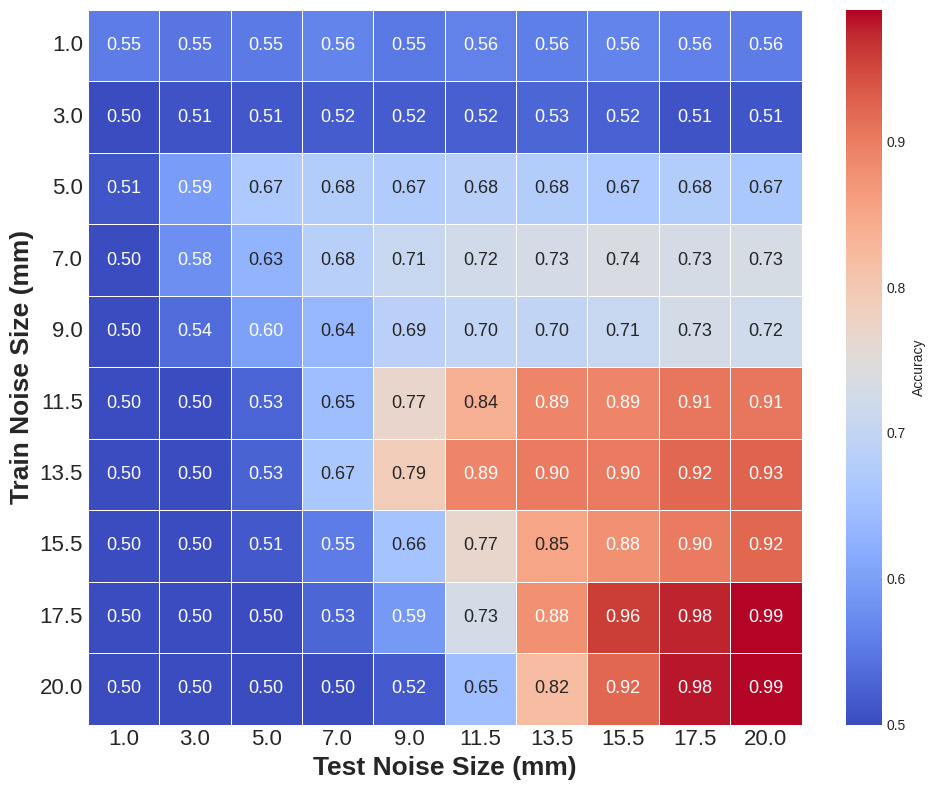

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

lbls = [int(2 + (40 - 2) * i / 9) * 0.5 for i in range(10)]
# Set up the plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    accuracy_table, 
    annot=True,           # Show accuracy values in each cell
    fmt=".2f",            # Format numbers to two decimal places
    cmap="coolwarm",      # Color gradient for the heatmap
    linewidths=0.5,       # Thin lines between cells for clarity
    cbar_kws={'label': 'Accuracy'},
    annot_kws={"fontsize": 13} 
)

# Customize the plot
# plt.title("Accuracy Heatmap", fontsize=18, pad=20)
plt.xlabel("Test Noise Size (mm)", fontsize=19, fontweight='bold')
plt.ylabel("Train Noise Size (mm)", fontsize=19, fontweight='bold')
plt.xticks(ticks=np.arange(10) + 0.5, labels=[f"{lbls[i]}" for i in range(10)], rotation=0, fontsize=16)
plt.yticks(ticks=np.arange(10) + 0.5, labels=[f"{lbls[i]}" for i in range(10)], rotation=0, fontsize=16)

# Show the plot
plt.tight_layout()
plt.savefig("eval_size_table.eps")
plt.show()


Claude improvement

In [49]:
[int(2 + (40 - 2) * i / 9) * 0.5 for i in range(10)]

[1.0, 3.0, 5.0, 7.0, 9.0, 11.5, 13.5, 15.5, 17.5, 20.0]

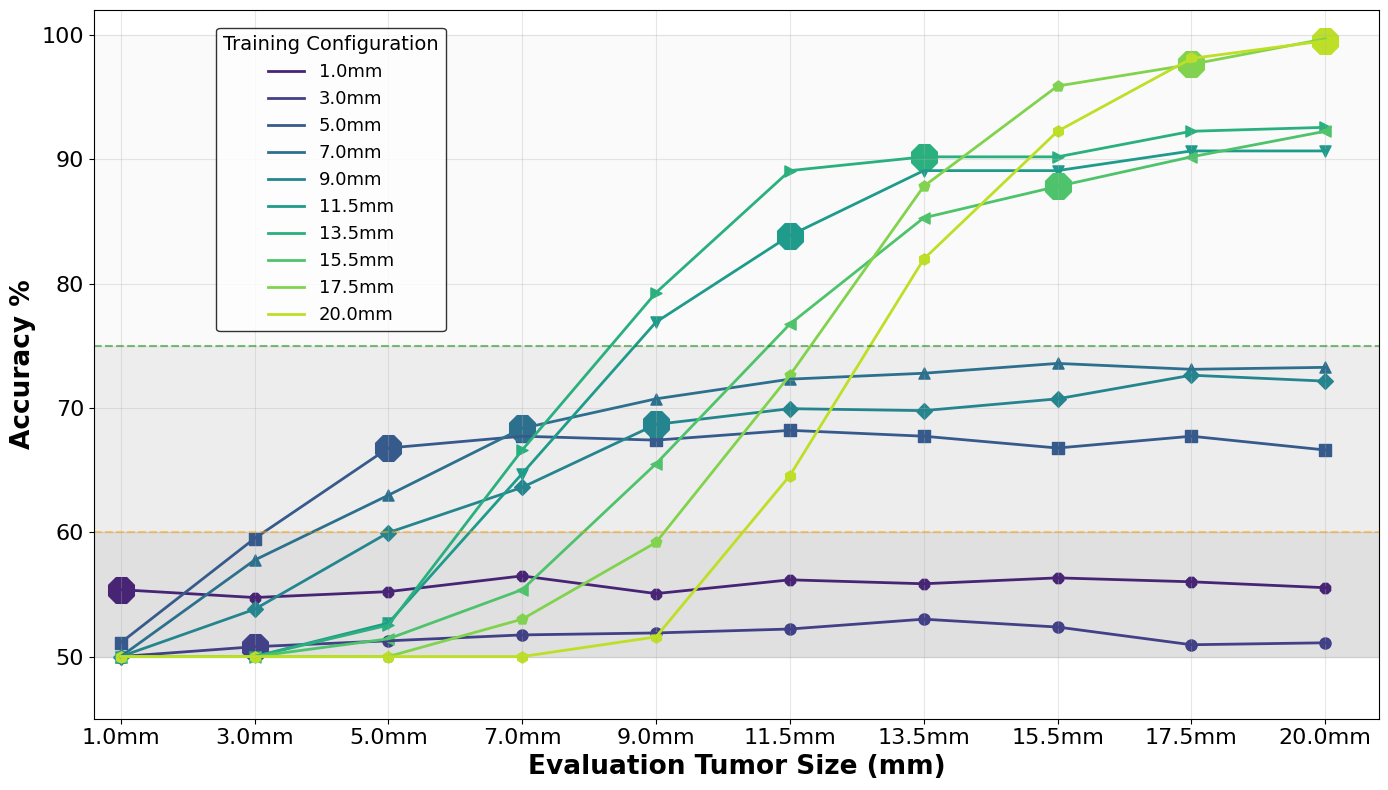

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tumor_size_performance(results, metric='accuracy', figsize=(14, 8)):
    """
    Create an enhanced visualization of model performance across different tumor sizes.

    Parameters:
    results (dict): Nested dictionary containing performance metrics
    metric (str): Metric to plot ('accuracy', 'precision', 'recall', 'f1')
    figsize (tuple): Figure size
    """
    plt.figure(figsize=figsize)

    # Setup
    noise_sizes = sorted(results[1].keys())
    markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', 'h', '8']
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, 10))
    lbls = [int(2 + (40 - 2) * i / 9) * 0.5 for i in range(10)]

    # Create background bands for better readability
    plt.axhspan(0.5, 0.6, color='lightgray', alpha=0.7)#, label='Poor performance')
    plt.axhspan(0.6, 0.75, color='lightgray', alpha=0.4)#, label='Moderate performance')
    plt.axhspan(0.75, 1.0, color='lightgray', alpha=0.1)#, label='Good performance')

    # Plot performance lines
    for train_size in range(10):
        metrics = [results[train_size][size][metric] for size in noise_sizes]
        metrics = [0.5 if m < 0.5 else m for m in metrics]
        # print(train_size, metrics)
        # if lbls[train_size] == 

        # Draw line connecting points
        plt.plot(noise_sizes, metrics,
                linestyle='-', 
                # marker=markers[train_size-1], 
                # markersize=20,
                linewidth=2, 
                color=colors[train_size], 
                label=f'{lbls[train_size]}mm')

        for i, noise_size in enumerate(noise_sizes):
            # print(lbls[train_size], lbls[noise_size])
            marker_size = 20 if lbls[train_size] == lbls[noise_size] else 8
            marker = "8" if lbls[train_size] == lbls[noise_size] else markers[train_size-1]
            plt.scatter(noise_size, metrics[i],
                        marker=marker,
                        s=marker_size**2,  # Matplotlib expects marker size in area
                        color=colors[train_size])
        # # Plot points with dynamic marker size
        # for test_size_idx, noise_size in enumerate(lbls):
        #     print(lbls[train_size], noise_size )

    # Fancy plot
    plt.xlabel('Evaluation Tumor Size (mm)', fontsize=19, fontweight='bold')
    plt.ylabel(f'{metric.capitalize()} %', fontsize=19, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=13)
    plt.xticks(ticks=range(10), labels=[f'{l}mm' for l in lbls], fontsize=16)
    plt.yticks(ticks=[i/10 for i in range(5,11, 1)], labels=[f'{k*10}' for k in range(5,11,1)], fontsize=16)

    # Different styles for major/minor lines
    plt.grid(True, which='major', linestyle='-', alpha=0.3)
    plt.grid(True, which='minor', linestyle=':', alpha=0.2)

    # Enhanced legend
    plt.legend(bbox_to_anchor=(.095, 0.975), 
               loc='upper left',
               fontsize=13,
               borderaxespad=0.,
               title='Training Configuration',
               title_fontsize=14,
               frameon=True,
                fancybox=True,
                edgecolor="black" )

    plt.ylim(0.45, 1.02)
    plt.xlim(-0.2, 9.4)
    plt.axhline(y=0.75, color='green', linestyle='--', alpha=0.5)
    plt.axhline(y=0.6, color='orange', linestyle='--', alpha=0.5)

    plt.tight_layout()
    return plt.gca()

# Example usage:
plot_tumor_size_performance(dic_res2, metric='accuracy')
plt.savefig("eval_size_all_var2.png")
# plt.savefig("eval_size_all_var2.")
plt.show()

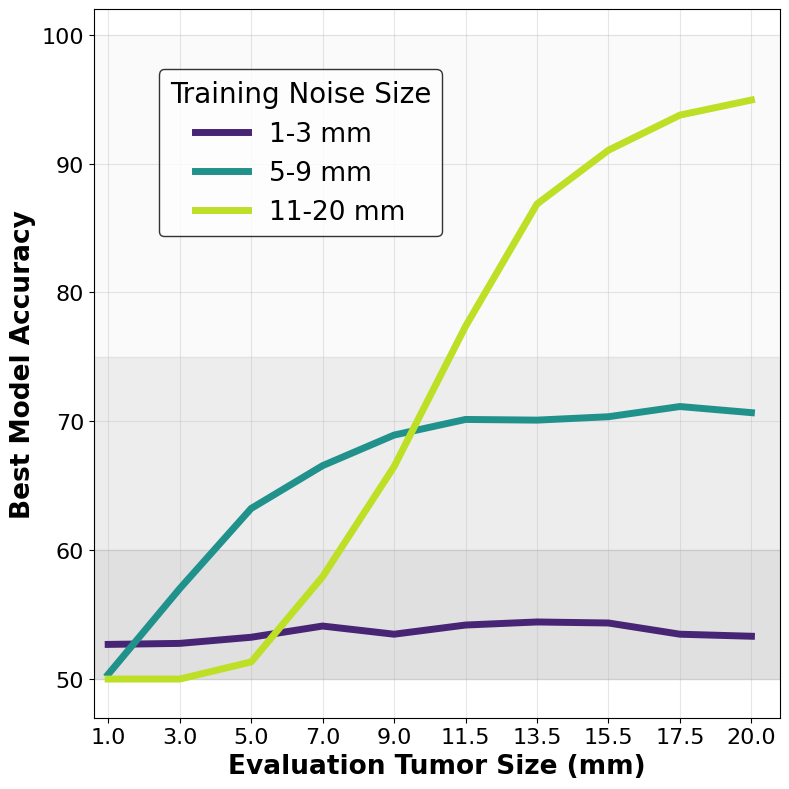

In [46]:
from cProfile import label


line_metrics = [] # lines to be plotted
dic_res2[0].keys()
noise_sizes = sorted(dic_res2[0].keys())
for train_size in range(10):
    metrics = [dic_res2[train_size][size]['accuracy'] for size in noise_sizes]
    metrics = [0.5 if m < 0.5 else m for m in metrics]
    line_metrics.append(metrics)

lines_simplified = [[],[],[]]
lines_simplified[0] = [(i+j)/2 for i,j in zip(line_metrics[0], line_metrics[1])]
lines_simplified[1] = [(i+j+k)/3 for i,j,k in zip(line_metrics[2], line_metrics[3], line_metrics[4])]
lines_simplified[2] = [(i+j+k+l+m)/5 for i,j,k,l,m in zip(line_metrics[5], line_metrics[6], line_metrics[7], line_metrics[8], line_metrics[9])]


plt.figure(figsize=(8, 8))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, 3))
x = range(10)
# Create background bands for better readability
plt.axhspan(0.5, 0.6, color='lightgray', alpha=0.7)#, label='Poor performance')
plt.axhspan(0.6, 0.75, color='lightgray', alpha=0.4)#, label='Moderate performance')
plt.axhspan(0.75, 1.0, color='lightgray', alpha=0.1)#, label='Good performance')

# for i, line in enumerate(lines_simplified):
plt.plot(x, lines_simplified[0], linewidth=5, color=colors[0], label ="1-3 mm")
plt.plot(x, lines_simplified[1], linewidth=5, color=colors[1], label ="5-9 mm")
plt.plot(x, lines_simplified[2], linewidth=5, color=colors[2], label ="11-20 mm")

plt.grid(True, alpha=0.3)
plt.xlabel('X', fontsize=19, fontweight='bold')
plt.ylabel('Y', fontsize=19, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.ylim(0.47, 1.02)
plt.xlim(-0.2, 9.4)
 # Fancy plot
plt.xlabel('Evaluation Tumor Size (mm)', fontsize=19, fontweight='bold')
plt.ylabel('Best Model Accuracy', fontsize=19, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=13)
lbls = [int(2 + (40 - 2) * i / 9) * 0.5 for i in range(10)]
plt.xticks(ticks=range(10), labels=[f'{l}' for l in lbls], fontsize=16)
plt.yticks(ticks=[i/10 for i in range(5,11, 1)], labels=[f'{k*10}' for k in range(5,11,1)], fontsize=16)

# Enhanced legend
plt.legend(bbox_to_anchor=(.095, 0.915), 
            loc='upper left',
            fontsize=19,
            borderaxespad=0.,
            title='Training Noise Size',
            title_fontsize=20,
            frameon=True,
            fancybox=True,
            edgecolor="black" )

plt.tight_layout()

ChatGPT

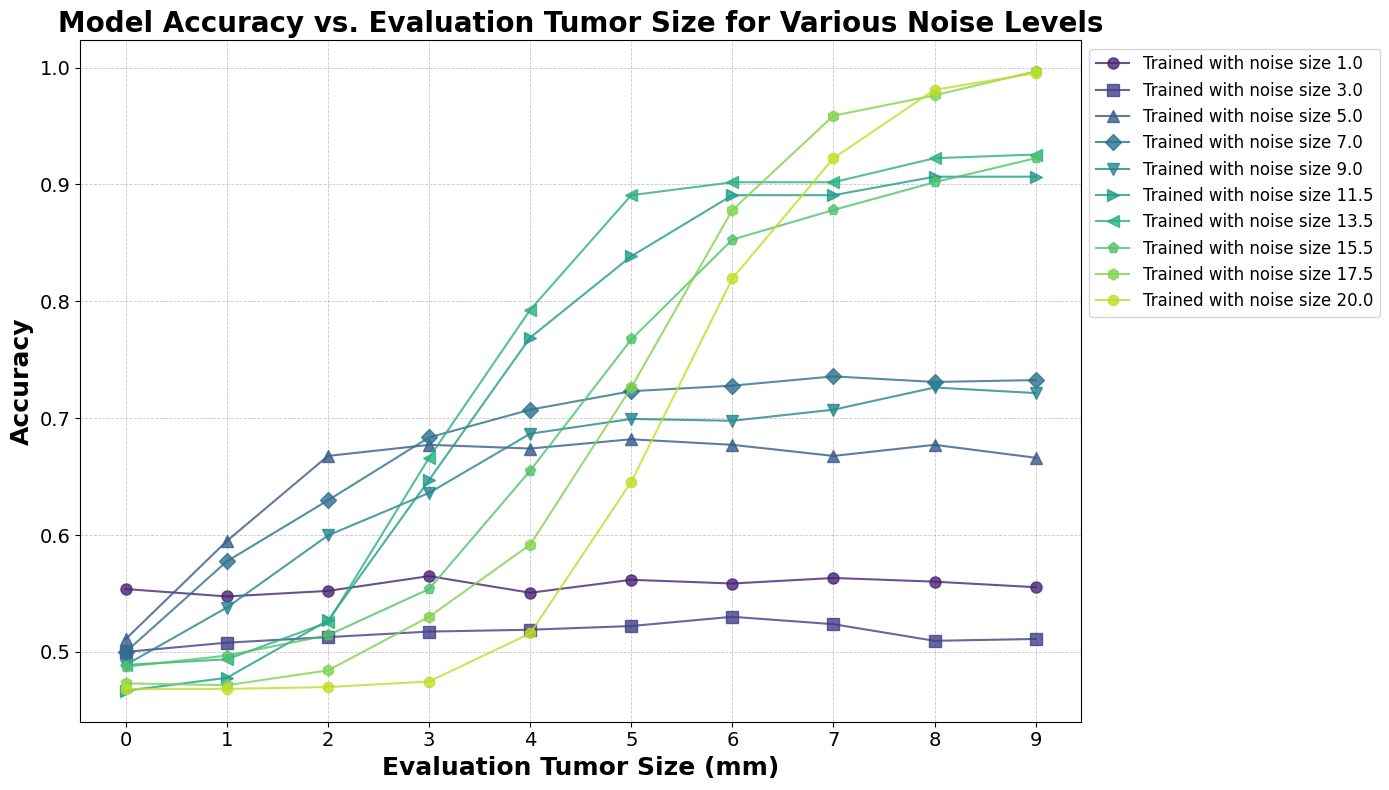

In [ ]:
def plot_accuracies2(results):
    plt.figure(figsize=(14, 8))

    noise_sizes = sorted(results[1].keys())
    markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', 'h', '8']
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, 10))
    lbls = [int(2 + (40 - 2) * i / 9) * 0.5 for i in range(10)]

    for train_size in range(10):
        accuracies = [results[train_size][size]['accuracy'] for size in noise_sizes]

        plt.plot(noise_sizes, accuracies, 
                 marker=markers[train_size], 
                 linestyle='-', 
                 linewidth=1.5,
                 markersize=8, 
                 alpha=0.8,
                 color=colors[train_size],
                 label=f'Trained with noise size {lbls[train_size]}')

    plt.xlabel('Evaluation Tumor Size (mm)', fontsize=18, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=18, fontweight='bold')
    plt.title('Model Accuracy vs. Evaluation Tumor Size for Various Noise Levels', fontsize=20, fontweight='bold')
    
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.xticks(ticks=noise_sizes)
    plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.7)

    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

plot_accuracies2(dic_res2)